**Simulate some data using your generative model**

For the simulation, we absorb constants for ease of coding and display. There should technically be a $\mu_0/(4\pi)$ in the dipole, and the gyromagnetic ratio for an electron should be used when determining $\Delta$. This will be incorporated when we implenent the model for real, right now I mostly care about the shape. 

I'm aiming to recreate data as seen in the image here, something along these lines:

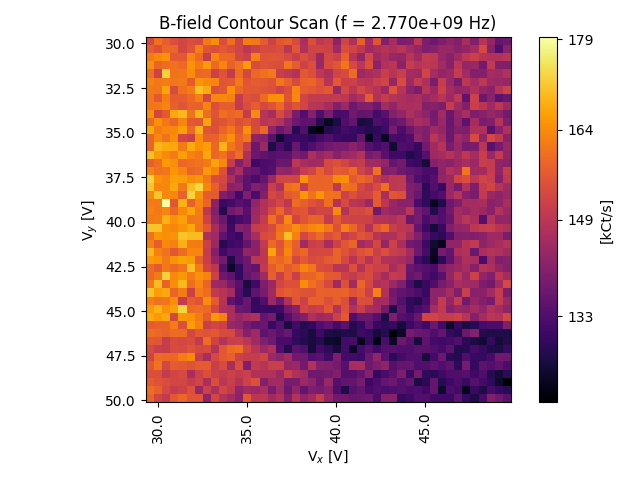

In [19]:
import numpy as np
import matplotlib.pyplot as plt

In [20]:
# ---------------------------------------
# Define some set parameters for the scan
# ---------------------------------------

n_pix = 45
vx = np.linspace(30.0, 50.0, n_pix)
vy = np.linspace(30.0, 50.0, n_pix)

VX, VY = np.meshgrid(vx, vy)

# ---------------------------------------
# We have a known volt -> um conversion
# ---------------------------------------
volt_to_um = 0.02
X = VX * volt_to_um
Y = VY * volt_to_um

# ---------------------------------------
# Our third dimension will be the image data
# ---------------------------------------
Z = np.zeros_like(X)

In [21]:
# ---------------------------------------
# Choose the TRUE parameter values
# ---------------------------------------

# dipole position, arbitrary position
x_d_true = 0.80
y_d_true = 0.81
z_d_true = -0.078

# Dipole moment (mostly z with small tilt)
m_vec_true = np.array([0.15, -0.08, 1.00])

# Our known NV axis
n_vec_true = np.array([0.0, 0.0, 1.00])

# Global Background
beta0_true = 145.0 #kc/s

# Lorentzian dip params
C_true = 0.30
Gamma_true = 40.0
delta0_true = 28.0

# Noise level?
sigma_true = 2.5 #kc/s

In [22]:
# ---------------------------------------------
# Simulate the noiseless image from true values
# ---------------------------------------------

mu_true, Bpar_true, Delta_true = mean_fluorescence(
    X, Y, Z, 
    x_d_true, y_d_true, z_d_true,
    m_vec_true,
    n_vec_true, 
    beta0_true,
    C_true, 
    Gamma_true,
    delta0_true
)

# And now draw noisy observations
rng = np.random.default_rng(1)
y_sim = rng.normal(loc=mu_true, scale=sigma_true, size=mu_true.shape)

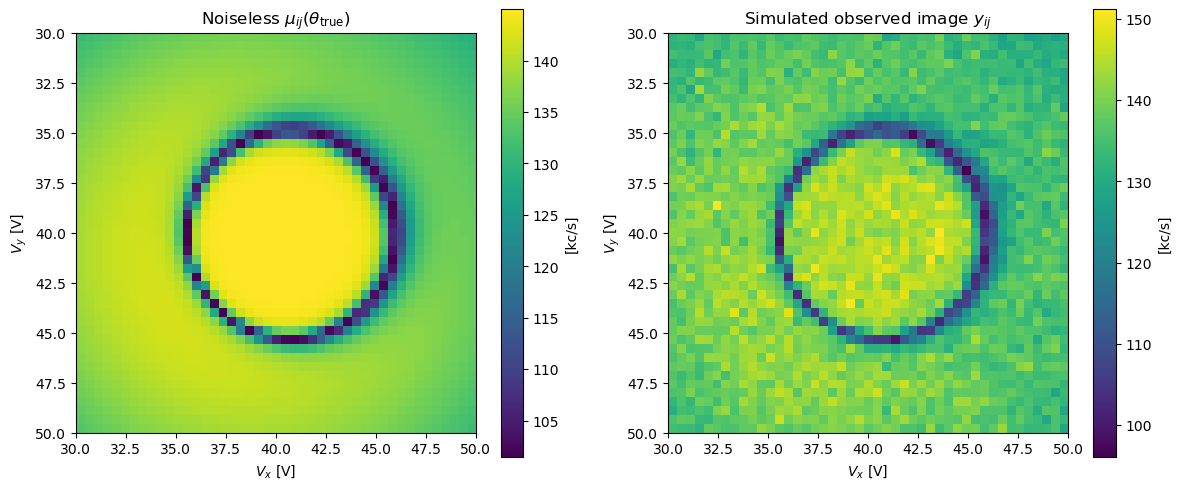

In [23]:
# -----------------------
# Plot our simulated data
# -----------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(mu_true,extent=[vx.min(), vx.max(), vy.max(), vy.min()])
axes[0].set_title("Noiseless $\\mu_{ij}(\\theta_{\\rm true})$")
axes[0].set_xlabel("$V_x$ [V]")
axes[0].set_ylabel("$V_y$ [V]")
plt.colorbar(im0, ax=axes[0], label="[kc/s]")

im1 = axes[1].imshow(y_sim, extent=[vx.min(), vx.max(), vy.max(), vy.min()])
axes[1].set_title("Simulated observed image $y_{ij}$")
axes[1].set_xlabel("$V_x$ [V]")
axes[1].set_ylabel("$V_y$ [V]")
plt.colorbar(im1, ax=axes[1], label="[kc/s]")

plt.tight_layout()
plt.show()

Which looks like a pretty close replica of the original image to me!

# (B) 4.

**Infer parameters from your simulated data**

In [24]:
import pymc as pm
import pytensor.tensor as pt
import arviz as az

Lets make our functions pytensor compatible so we can use them with PyMC:

C:\Users\Brandon\miniforge3\envs\phys201\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [d, C, beta0, x_d, y_d, delta0, Gamma]


Output()

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 85 seconds.


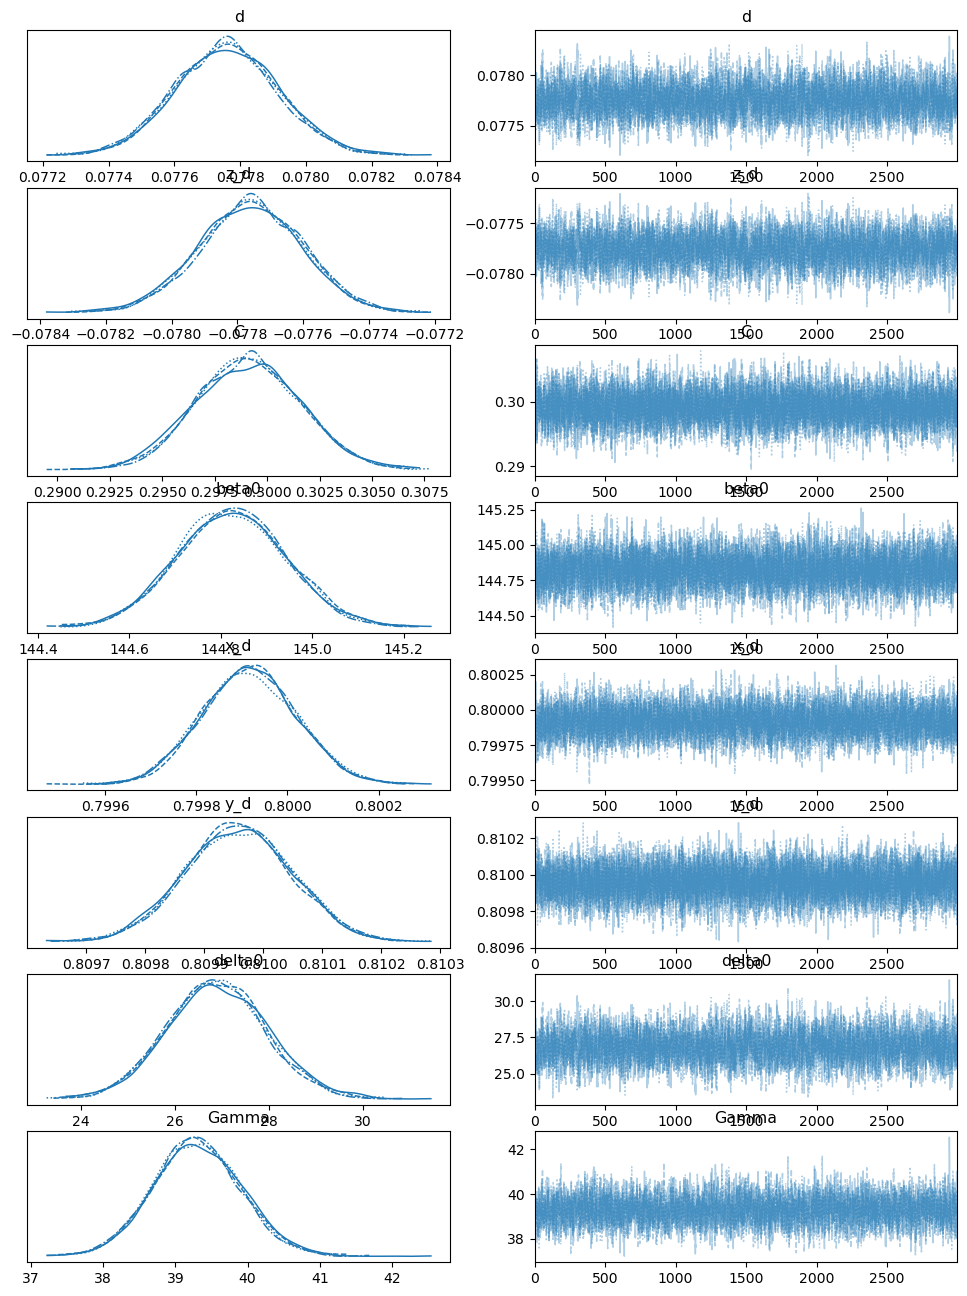

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
d,0.078,0.000,0.077,0.078,0.000,0.000,3786.0,5525.0,1.0
z_d,-0.078,0.000,-0.078,-0.077,0.000,0.000,3786.0,5525.0,1.0
C,0.299,0.003,0.294,0.304,0.000,0.000,9074.0,8157.0,1.0
beta0,144.824,0.118,144.598,145.039,0.001,0.001,7605.0,7708.0,1.0
x_d,0.800,0.000,0.800,0.800,0.000,0.000,6210.0,7444.0,1.0
y_d,0.810,0.000,0.810,0.810,0.000,0.000,8358.0,8345.0,1.0
delta0,26.889,1.054,24.968,28.940,0.017,0.011,3739.0,4953.0,1.0
Gamma,39.300,0.606,38.138,40.410,0.010,0.006,4037.0,5860.0,1.0


In [25]:
with pm.Model() as nv_model:

    X_shared = pm.Data("X_shared", X.astype("float64"))
    Y_shared = pm.Data("Y_shared", Y.astype("float64"))
    Z_shared = pm.Data("Z_shared", Z.astype("float64"))
    y_shared = pm.Data("y_shared", y_sim.astype("float64"))

    # Giving the model something easy to work with here...
    d = pm.Normal("d", mu=0.078, sigma=0.02)
    z_d = pm.Deterministic("z_d", -d)

    # From 0-1, average of 0.3, weighted towards lower values
    C = pm.Beta("C", alpha=2.0, beta=5.0)

    # Take average count from data set as guess
    beta0 = pm.Normal("beta0", mu=float(np.mean(y_sim)), sigma=10.0)

    # Uniform across um range
    x_d = pm.Uniform("x_d", lower=0.55, upper=1.05)
    y_d = pm.Uniform("y_d", lower=0.55, upper=1.05)

    # limited by some instrument or NV property?
    delta0 = pm.Uniform("delta0", lower=-40.0, upper=40.0)

    # also trying to make this distribution as easy as possible right now
    Gamma = pm.Exponential("Gamma", lam=1/40.0)

    # Adding values of m_x, m_y, m_z breaks HMC model
    # m_x = pm.Normal("m_x", mu=0.0, sigma=0.5)

    mu_model, B_par, Delta = mean_fluorescence_pt(
        X_shared, Y_shared, Z_shared,
        x_d, y_d, z_d,
        m_vec_true[0], m_vec_true[1], m_vec_true[2],
        beta0, C, Gamma, delta0,
        n_vec_true
    )

    y_like = pm.Normal("y_like", mu=mu_model, sigma=sigma_true, observed=y_shared)

with nv_model:
    nv_samples = pm.sample(
        tune=3000,
        draws=3000,
        chains=4,
        init="adapt_diag",
        target_accept=0.9,
        random_seed=11,
        return_inferencedata=True
    )

az.plot_trace(nv_samples, var_names=["d", "z_d", "C", "beta0", "x_d", "y_d", "delta0", "Gamma"])
plt.show()

az.summary(nv_samples, var_names=["d", "z_d", "C", "beta0", "x_d", "y_d", "delta0", "Gamma"])

In [18]:
az.plot_pair(
    nv_samples,
    var_names=["z_d", "C", "beta0", "x_d", "y_d", "delta0", "Gamma"],
    kind="kde",
    marginals=True
)

array([[<Axes: ylabel='z_d'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >],
       [<Axes: ylabel='C'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >],
       [<Axes: ylabel='beta0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >],
       [<Axes: ylabel='x_d'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >],
       [<Axes: ylabel='y_d'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >],
       [<Axes: ylabel='delta0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >],
       [<Axes: xlabel='z_d', ylabel='Gamma'>, <Axes: xlabel='C'>,
        <Axes: xlabel='beta0'>, <Axes: xlabel='x_d'>,
        <Axes: xlabel='y_d'>, <Axes: xlabel='delta0'>,
        <Axes: xlabel='Gamma'>]], dtype=object)

We see that z_d and $\delta_0$ are highly coorelated. This makes sense, because $\delta_0$ represetns the offset from the resonant condition. So, the ring in the image is the place where $\delta_0 = B_\parallel$, i.e. it is the level set of the dipole field. So, if $z_d$ increases, then the field weakens, then the model can reduce $\delta_0$ so that the resonance condition happens at a similar contour. But in our case, maybe this is something that will be fixes based on given knowledge. 

**NOTE:** Letting the dipole vector be a free parameter really breaks the HMC simulation. I think this is becuase the system becomes extremely unconstrained, eg small tilts in the dipole could compeltely change the x or y interpretation, the delta intepretation, it probably creates a landscape which is super unfriendly to HMC. 

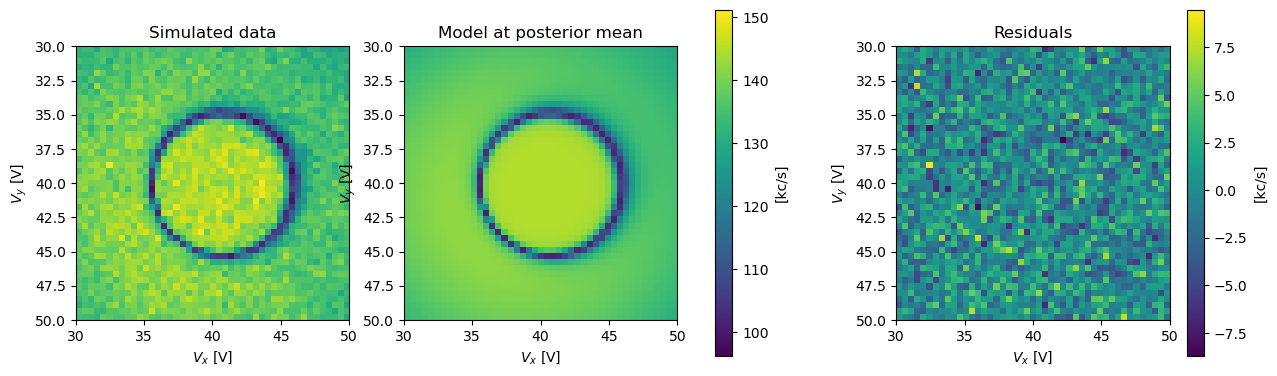

In [23]:
summary = az.summary(nv_samples, var_names=["x_d", "y_d", "z_d", "C", "beta0", "delta0", "Gamma"])

x_mean = summary.loc["x_d", "mean"]
y_mean = summary.loc["y_d", "mean"]
z_mean = summary.loc["z_d", "mean"]
C_mean = summary.loc["C", "mean"]
beta0_mean = summary.loc["beta0", "mean"]
delta0_mean = summary.loc["delta0", "mean"]
Gamma_mean = summary.loc["Gamma", "mean"]

mu_fit, _, _ = mean_fluorescence(
    X, Y, Z,
    x_mean, y_mean, z_mean,
    m_vec_true,
    n_vec_true,
    beta0_mean,
    C_mean,
    Gamma_mean,
    delta0_mean
)

# Residuals
residual = y_sim - mu_fit

# Match color scales for viewing purppose
vmin = min(y_sim.min(), mu_fit.min())
vmax = max(y_sim.max(), mu_fit.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

im0 = axes[0].imshow(
    y_sim,
    extent=[vx.min(), vx.max(), vy.max(), vy.min()],
    vmin=vmin, vmax=vmax
)
axes[0].set_title("Simulated data")
axes[0].set_xlabel("$V_x$ [V]")
axes[0].set_ylabel("$V_y$ [V]")

im1 = axes[1].imshow(
    mu_fit,
    extent=[vx.min(), vx.max(), vy.max(), vy.min()],
    vmin=vmin, vmax=vmax
)
axes[1].set_title("Model at posterior mean")
axes[1].set_xlabel("$V_x$ [V]")
axes[1].set_ylabel("$V_y$ [V]")

im2 = axes[2].imshow(
    residual,
    extent=[vx.min(), vx.max(), vy.max(), vy.min()],
)
axes[2].set_title("Residuals")
axes[2].set_xlabel("$V_x$ [V]")
axes[2].set_ylabel("$V_y$ [V]")

plt.colorbar(im0, ax=axes[:2], label="[kc/s]")
plt.colorbar(im2, ax=axes[2], label="[kc/s]")

plt.show()

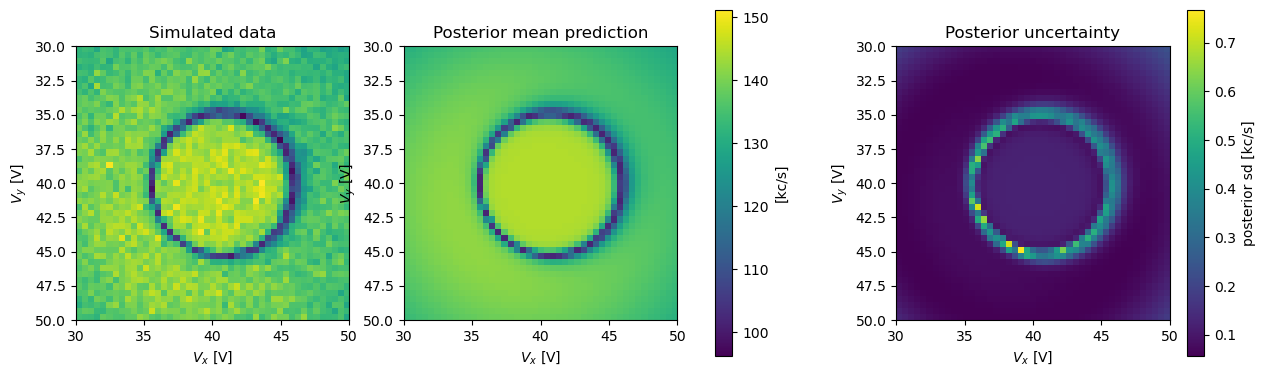

In [24]:
posterior = nv_samples.posterior

x_samps = posterior["x_d"].stack(sample=("chain", "draw")).values
y_samps = posterior["y_d"].stack(sample=("chain", "draw")).values
z_samps = posterior["z_d"].stack(sample=("chain", "draw")).values
C_samps = posterior["C"].stack(sample=("chain", "draw")).values
beta0_samps = posterior["beta0"].stack(sample=("chain", "draw")).values
delta0_samps = posterior["delta0"].stack(sample=("chain", "draw")).values
Gamma_samps = posterior["Gamma"].stack(sample=("chain", "draw")).values

# only use a random subset here of our posteriors
rng = np.random.default_rng(0)
n_keep = min(300, len(x_samps))
idx = rng.choice(len(x_samps), size=n_keep, replace=False)

# now we want to compute an image for each draw
mu_samples = []
for k in idx:
    mu_k, _, _ = mean_fluorescence(
        X, Y, Z,
        x_samps[k], y_samps[k], z_samps[k],
        m_vec_true,
        n_vec_true,
        beta0_samps[k],
        C_samps[k],
        Gamma_samps[k],
        delta0_samps[k]
    )
    mu_samples.append(mu_k)

mu_samples = np.array(mu_samples)

# With many samples, we can take mean AND St Dev
mu_post_mean = mu_samples.mean(axis=0)
mu_post_std = mu_samples.std(axis=0)

# Finally plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# scale color bars
vmin = min(y_sim.min(), mu_post_mean.min())
vmax = max(y_sim.max(), mu_post_mean.max())

im0 = axes[0].imshow(
    y_sim,
    extent=[vx.min(), vx.max(), vy.max(), vy.min()],
    vmin=vmin, vmax=vmax
)
axes[0].set_title("Simulated data")
axes[0].set_xlabel("$V_x$ [V]")
axes[0].set_ylabel("$V_y$ [V]")

im1 = axes[1].imshow(
    mu_post_mean,
    extent=[vx.min(), vx.max(), vy.max(), vy.min()],
    vmin=vmin, vmax=vmax
)
axes[1].set_title("Posterior mean prediction")
axes[1].set_xlabel("$V_x$ [V]")
axes[1].set_ylabel("$V_y$ [V]")

im2 = axes[2].imshow(
    mu_post_std,
    extent=[vx.min(), vx.max(), vy.max(), vy.min()],
)
axes[2].set_title("Posterior uncertainty")
axes[2].set_xlabel("$V_x$ [V]")
axes[2].set_ylabel("$V_y$ [V]")

plt.colorbar(im0, ax=axes[:2], label="[kc/s]")
plt.colorbar(im2, ax=axes[2], label="posterior sd [kc/s]")

plt.show()